# Download bibliotecas

In [1]:
!pip install numpy==1.23.5 pandas==2.2.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 51.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.4.3 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
albucore 0.0.24 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
albumentations 2.0.8 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.23.5 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.23.5 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.23.5 which is incompatible.
bigfra

In [1]:
!pip install pmdarima

# Importando dados

In [2]:
import pandas as pd
import os
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

caminho_dados = '/content/drive/Shareddrives/IC - Otimizacao computacional para inflacao/Dados/dados_USA'

# Listar os arquivos dentro da pasta "Dados"
arquivos_dados = os.listdir(caminho_dados)

print(arquivos_dados)


Mounted at /content/drive
['Untitled0.ipynb', 'dados_macroeconomicos_usa.csv']


In [14]:
file_path = os.path.join(caminho_dados, 'dados_macroeconomicos_usa.csv')

df = pd.read_csv(file_path, parse_dates=True)


In [15]:
df.set_index('DATE', inplace=True)

In [16]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180 entries, 2010-01-01 to 2024-12-01
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Inflacao_CPI                 180 non-null    float64
 1   Inflacao_CPI_Core            180 non-null    float64
 2   PCE_Core                     180 non-null    float64
 3   Desemprego                   180 non-null    float64
 4   Desemprego_menos_27_semanas  180 non-null    float64
 5   Taxa_Juros_Fed               180 non-null    float64
 6   Emprego_Total_Nao_Agricola   180 non-null    int64  
 7   Permissoes_Construcao        180 non-null    int64  
 8   Salario_Medio                180 non-null    float64
 9   Salario_Medio_Real_Hora      180 non-null    float64
 10  Producao_Industrial          180 non-null    float64
 11  Capacidade_Instalada         180 non-null    float64
 12  PCE                          180 non-null    float64
 13  Deflator_

# Funcoes auxiliares

In [19]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Funções auxiliares

def make_stationary(df, max_diff=5):
    """Torna a série temporal estacionária através de diferenciação."""
    df_diff = df.copy()
    for i in range(1, max_diff + 1):
        stationary = True
        for column in df_diff.columns:
            if not check_stationarity(df_diff[[column]]):
                stationary = False
                df_diff[[column]] = df_diff[[column]].diff().fillna(method='ffill').fillna(method='bfill')
        if stationary:
            print(f"Série estacionária após {i-1} diferenciações.")
            return df_diff.dropna()
    raise ValueError("A série não se tornou estacionária após o número máximo de diferenciações.")

def check_stationarity(series, significance_level=0.05):
    """Verifica se a série é estacionária usando o teste ADF."""
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(series.dropna())
    return result[1] < significance_level

def plot_forecasts(y_test, final_forecast, title='Previsão Dinâmica'):
    """Plota as previsões comparadas com os valores reais."""
    plt.figure(figsize=(15, 3))
    plt.plot(y_test.index, y_test, label='Valores Reais', color='blue')
    plt.plot(y_test.index, final_forecast, label='Previsão', color='orange')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# Implementacao Arima

In [20]:
import warnings

# Ignorar todos os warnings
warnings.filterwarnings("ignore")


Série estacionária após 2 diferenciações.
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=274.464, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=312.107, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=314.050, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=313.963, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=275.658, Time=0.20 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=272.474, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=285.076, Time=0.48 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=300.652, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=274.459, Time=0.60 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=290.889, Time=0.13 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=276.391, Time=1.81 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=3.29 sec

Best model:  ARIMA(2,0,1)(0,0,0)[0]          
Total fit time: 7.088 seconds
MAE: 0.839931
MSE: 1.234720
RMSE: 1.111180
MAPE: 1.340883


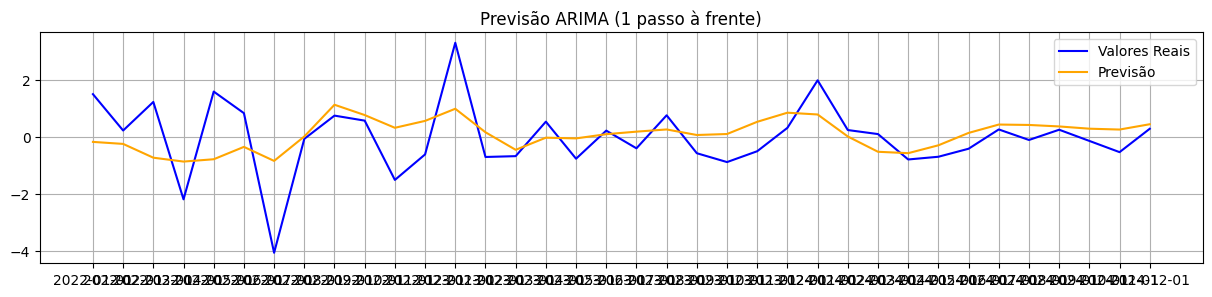

In [21]:
target = 'Inflacao_CPI'
# Função principal
if __name__ == "__main__":
    # Tornar o DataFrame estacionário
    df_stationary = make_stationary(df)

    # Dividir em conjunto de treino e teste
    train_size = int(len(df_stationary) * 0.8)
    train, test = df_stationary.iloc[:train_size], df_stationary.iloc[train_size:]

    # Variável dependente
    y_train = train[target]
    y_test = test[target]

    # Ajuste do modelo ARIMA usando pmdarima (sem sazonalidade)
    arima_model = auto_arima(y_train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
    arima_order = arima_model.order

    # Previsão dinâmica com ARIMA no conjunto de teste para 1 passo à frente
    history = list(y_train)
    dynamic_arima_forecast = []

    for t in range(len(y_test)):
        # Ajuste do modelo SARIMAX dinamicamente para 1 passo
        arima_dynamic = SARIMAX(history, order=arima_order).fit(disp=False)
        arima_pred = arima_dynamic.forecast(steps=1)
        dynamic_arima_forecast.append(arima_pred[0])

        # Atualizar o histórico de variáveis dependentes
        history.append(y_test.iloc[t])

    # Calcular e salvar as previsões finais
    final_forecast_df = pd.DataFrame(dynamic_arima_forecast, index=y_test.index[:len(dynamic_arima_forecast)], columns=['Final_Forecast'])
    final_forecast_df.to_csv('arima_pred.csv', index=True)

    # Salvar o modelo ARIMA
    joblib.dump(arima_model, 'arima_model.pkl')  # Salva o modelo

    # Calcular os resíduos
    residuals = y_test[:len(dynamic_arima_forecast)] - dynamic_arima_forecast
    residuals_df = pd.DataFrame(residuals, index=y_test.index[:len(dynamic_arima_forecast)], columns=['Residuals'])
    residuals_df.to_csv('arima_res.csv', index=True)  # Salva os resíduos

    # Métricas de erro
    mse = mean_squared_error(y_test[:len(dynamic_arima_forecast)], dynamic_arima_forecast)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test[:len(dynamic_arima_forecast)], dynamic_arima_forecast)
    mape = np.mean(np.abs((y_test[:len(dynamic_arima_forecast)] - dynamic_arima_forecast) / y_test[:len(dynamic_arima_forecast)]))
    r2 = r2_score(y_test[:len(dynamic_arima_forecast)], dynamic_arima_forecast)

    print(f'MAE: {mae:.6f}')
    print(f'MSE: {mse:.6f}')
    print(f'RMSE: {rmse:.6f}')
    print(f'MAPE: {mape:.6f}')

    # Plotar as previsões
    plot_forecasts(y_test[:len(dynamic_arima_forecast)], dynamic_arima_forecast, title='Previsão ARIMA (1 passo à frente)')

# Implementacao Arima + RF


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Obter os resíduos do ARIMA
residuals = y_test[:len(dynamic_arima_forecast)] - dynamic_arima_forecast
residuals = residuals.reset_index(drop=True)

# Features para o Random Forest (todas exceto a variável alvo)
X_rf = test.drop(columns=[target]).iloc[:len(residuals)].reset_index(drop=True)

# Alvo: resíduos do ARIMA
y_rf = residuals

# Dividir dados para treino e teste do Random Forest
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

# Treinar modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)


RandomForestRegressor(random_state=42)

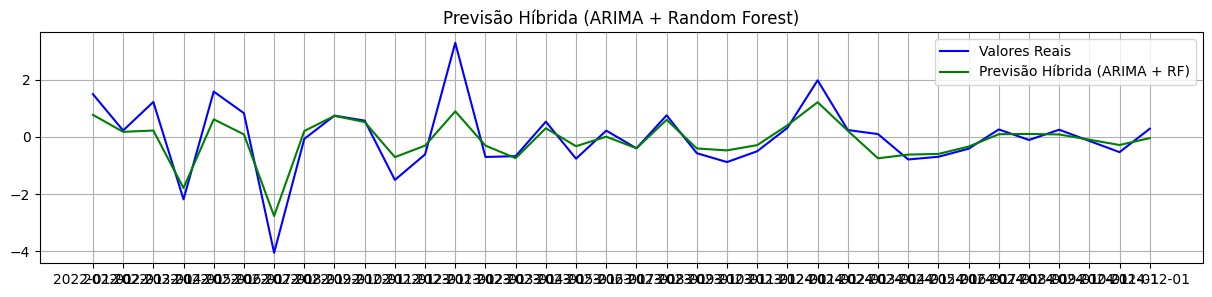


--- Métricas do Modelo Híbrido (ARIMA + Random Forest) ---
MAE: 0.403058
MSE: 0.380786
RMSE: 0.617079
MAPE: 0.792238


In [23]:
# Prever os resíduos com o modelo Random Forest
rf_predicted_residuals = rf_model.predict(X_rf)

# Somar a previsão do ARIMA com a previsão dos resíduos
hybrid_forecast = np.array(dynamic_arima_forecast) + rf_predicted_residuals

# Plotando o modelo híbrido
plt.figure(figsize=(15, 3))
plt.plot(y_test.index[:len(hybrid_forecast)], y_test[:len(hybrid_forecast)], label='Valores Reais', color='blue')
plt.plot(y_test.index[:len(hybrid_forecast)], hybrid_forecast, label='Previsão Híbrida (ARIMA + RF)', color='green')
plt.title('Previsão Híbrida (ARIMA + Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

# Cálculo das métricas
mae_hybrid = mean_absolute_error(y_test[:len(hybrid_forecast)], hybrid_forecast)
mse_hybrid = mean_squared_error(y_test[:len(hybrid_forecast)], hybrid_forecast)
rmse_hybrid = np.sqrt(mse_hybrid)
mape_hybrid = np.mean(np.abs((y_test[:len(hybrid_forecast)] - hybrid_forecast) / y_test[:len(hybrid_forecast)]))

# Impressão dos resultados
print("\n--- Métricas do Modelo Híbrido (ARIMA + Random Forest) ---")
print(f'MAE: {mae_hybrid:.6f}')
print(f'MSE: {mse_hybrid:.6f}')
print(f'RMSE: {rmse_hybrid:.6f}')
print(f'MAPE: {mape_hybrid:.6f}')
